# Repair Results Analysis

This notebook loads repair results from SQLite databases and generates summary statistics and visualizations.


In [10]:
import os
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
%matplotlib inline

In [12]:
def load_results():
    """Load repair results from all matching SQLite DB files into a DataFrame."""
    db_files = [f for f in os.listdir('.') if f.startswith('repair_results_') and f.endswith('.db')]
    if not db_files:
        print("No repair_results_*.db files found in the current directory.")
        return None
    dfs = []
    for db_file in db_files:
        name = os.path.splitext(db_file)[0]
        parts = name.split('_')
        # Expect format: repair_results_{backend}_{model}_{src}
        if len(parts) < 4:
            print(f"Skipping unrecognized file name format: {db_file}")
            continue
        _, _, backend, model, *rest = parts
        src = '_'.join(rest)
        conn = sqlite3.connect(db_file)
        df = pd.read_sql_query('SELECT * FROM repair_results', conn)
        conn.close()
        df['backend'] = backend
        df['model'] = model
        df['src'] = src
        # Attempt to load mutation_depth from source cases DB (<src>.db)
        src_db = f"{src}.db"
        if os.path.exists(src_db):
            try:
                src_conn = sqlite3.connect(src_db)
                cases_df = pd.read_sql_query('SELECT id AS case_id, mutation_depth FROM cases', src_conn)
                src_conn.close()
                df = df.merge(cases_df, on='case_id', how='left')
            except Exception:
                df['mutation_depth'] = None
        dfs.append(df)
    if not dfs:
        return None
    results_df = pd.concat(dfs, ignore_index=True)
    results_df['ratio'] = results_df['passed_tests'] / results_df['total_tests']
    results_df['fixed'] = results_df['fix'] == 1
    return results_df

In [13]:
# Example usage
sns.set(style='whitegrid')
df = load_results()
if df is not None:
    print("Summary:")
    print(df.head())

Summary:
   case_id  dim  recursive_prob  loop_prob  total_tests  passed_tests  fix  \
0        1    1             0.1        0.9            5             5    1   
1        2    1             0.2        0.2            5             5    1   
2        3    1             0.2        0.5            5             5    1   
3        4    1             0.4        0.4            5             5    1   
4        5    1             0.4        0.9            5             5    1   

  backend               model       src  mutation_depth  ratio  fixed  
0  openai  o1-mini-2024-09-12  targets2               1    1.0   True  
1  openai  o1-mini-2024-09-12  targets2               1    1.0   True  
2  openai  o1-mini-2024-09-12  targets2               1    1.0   True  
3  openai  o1-mini-2024-09-12  targets2               1    1.0   True  
4  openai  o1-mini-2024-09-12  targets2               1    1.0   True  


/var/folders/4p/mcvjxqjj0f32176nf_3wv1gc0000gt/T/ipykernel_68245/4127561982.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='mutation_depth', y='fixed', hue='model', data=df, ci='sd')


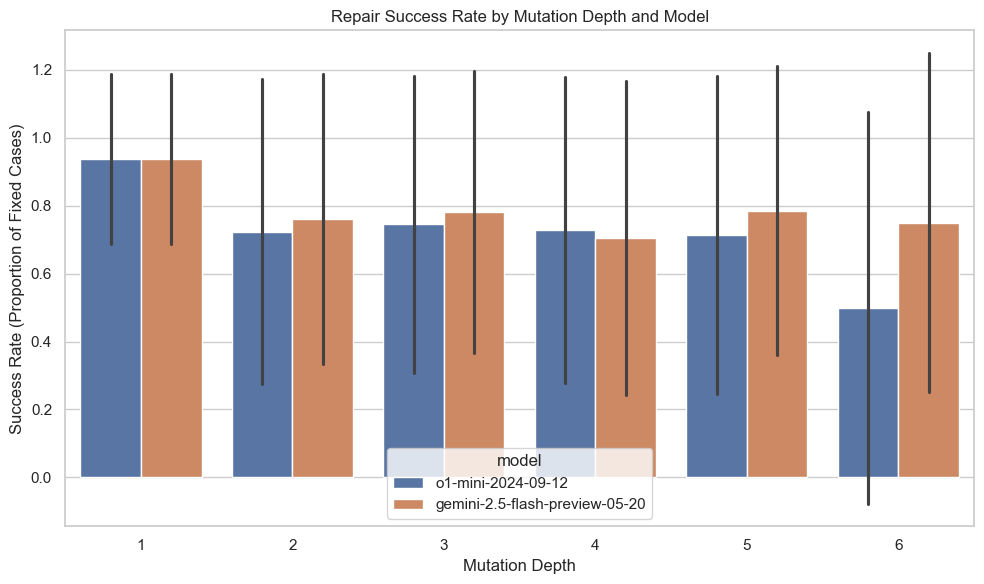

In [14]:
# Repair success rate by mutation depth for each model
if df is not None and 'mutation_depth' in df.columns:
    plt.figure(figsize=(10,6))
    sns.barplot(x='mutation_depth', y='fixed', hue='model', data=df, ci='sd')
    plt.title('Repair Success Rate by Mutation Depth and Model')
    plt.ylabel('Success Rate (Proportion of Fixed Cases)')
    plt.xlabel('Mutation Depth')
    plt.tight_layout()
    plt.show()

/var/folders/4p/mcvjxqjj0f32176nf_3wv1gc0000gt/T/ipykernel_68245/3328937960.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='dim', y='fixed', hue='model', data=df, ci='sd')


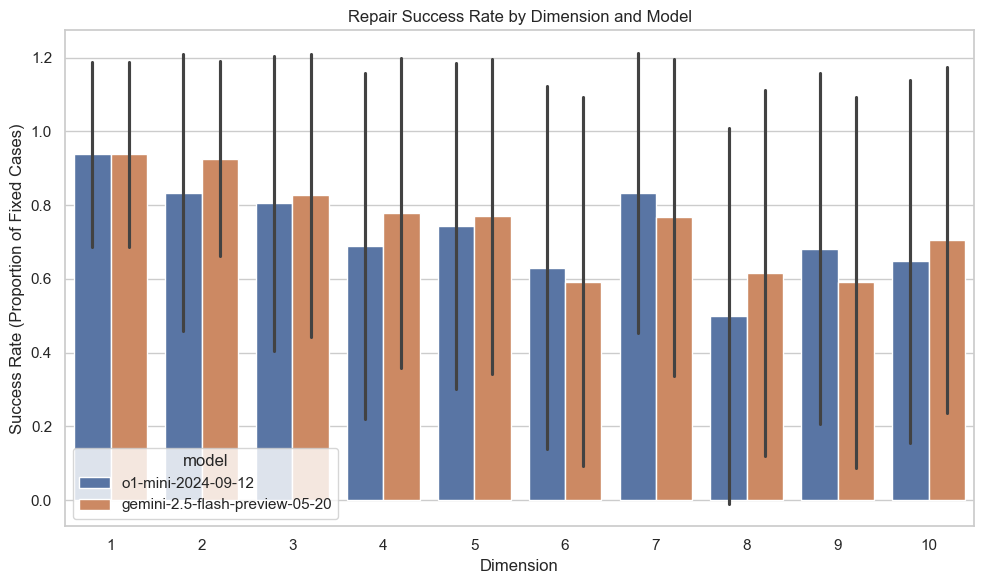

In [17]:
# Repair success rate by dimension for each model
if df is not None and 'dim' in df.columns:
    plt.figure(figsize=(10,6))
    sns.barplot(x='dim', y='fixed', hue='model', data=df, ci='sd')
    plt.title('Repair Success Rate by Dimension and Model')
    plt.ylabel('Success Rate (Proportion of Fixed Cases)')
    plt.xlabel('Dimension')
    plt.tight_layout()
    plt.show()


/var/folders/4p/mcvjxqjj0f32176nf_3wv1gc0000gt/T/ipykernel_68245/33863094.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x='recursive_prob', y='fixed', hue='model', data=df, ci='sd')


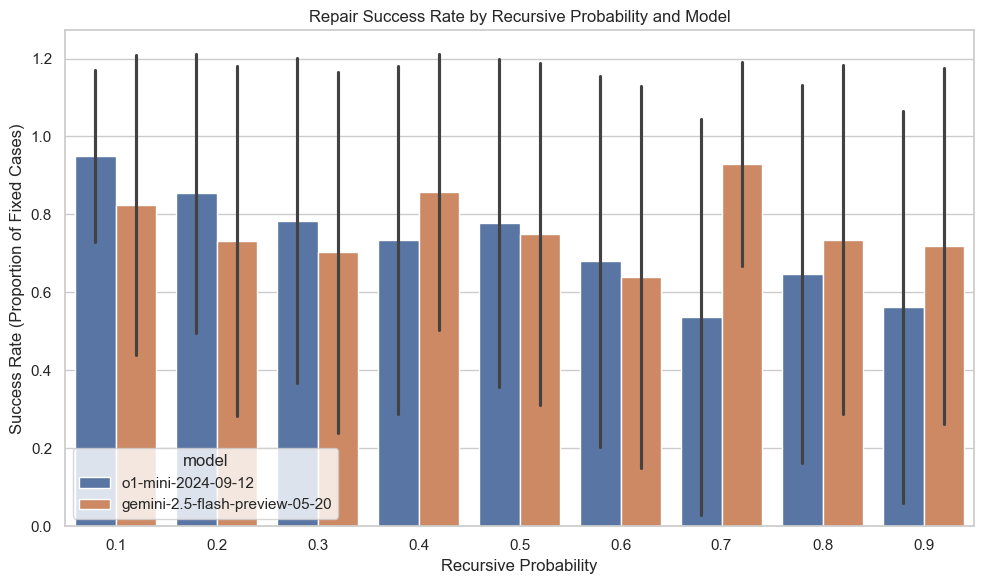

In [18]:
# Repair success rate by recursive_prob for each model
if df is not None and 'recursive_prob' in df.columns:
    plt.figure(figsize=(10,6))
    sns.barplot(x='recursive_prob', y='fixed', hue='model', data=df, ci='sd')
    plt.title('Repair Success Rate by Recursive Probability and Model')
    plt.ylabel('Success Rate (Proportion of Fixed Cases)')
    plt.xlabel('Recursive Probability')
    plt.tight_layout()
    plt.show()
